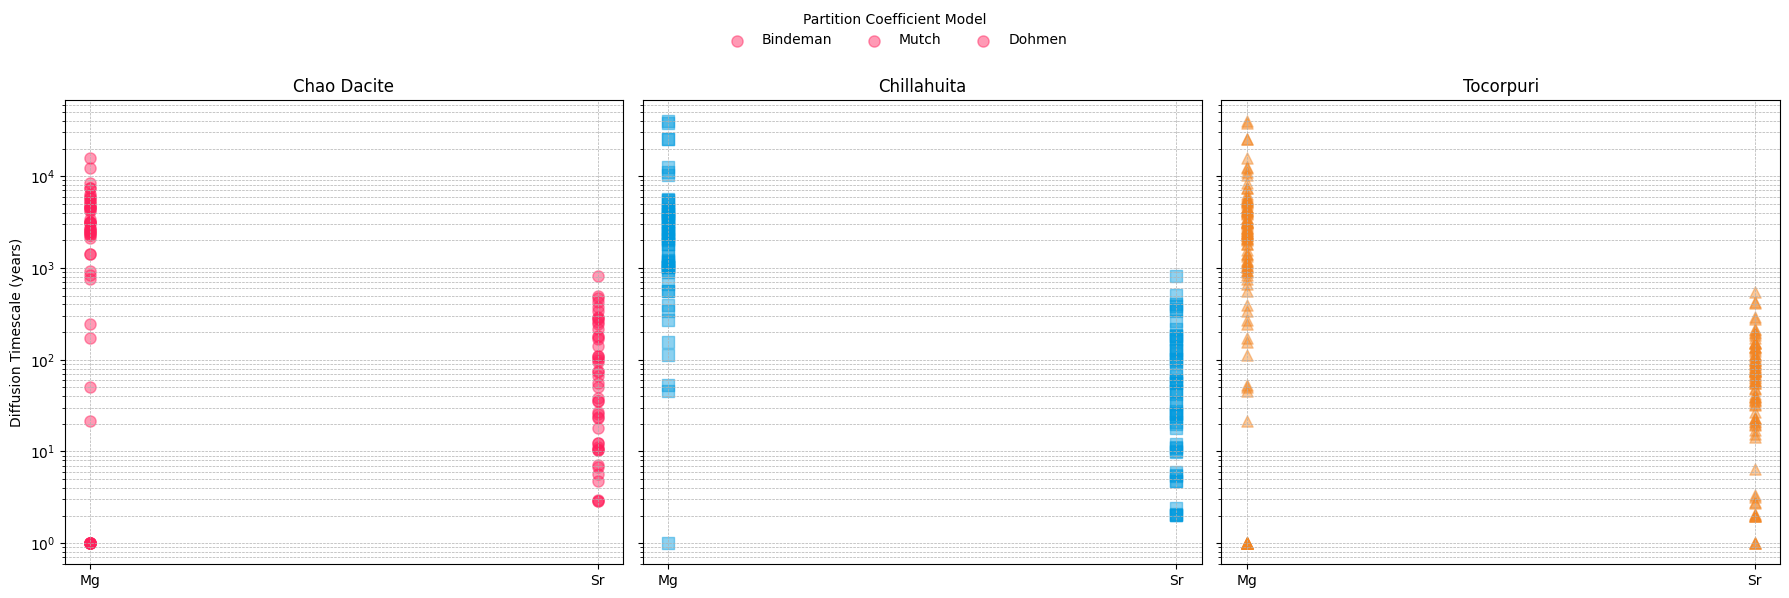

In [12]:
# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Shift Mg and Sr toward the center
x_map = {"Mg": 0.4, "Sr": 0.6}

for ax, (dome, info) in zip(axes, DOMES.items()):
    subset = data[data["Dome"] == dome]

    for model in ["Bindeman et al., (1998)", "Mutch et al., (2021)", "Dohmen et al., (2017)"]:
        s = subset[subset["Partition_Model"] == model]

        ax.scatter(
            s["Element"].map(x_map),
            s["mc_mean_yrs"],
            color=info["color"],
            marker=MODEL_MARKERS[model],
            alpha=0.6,
            s=70,
            label=model
        )

    # Bold dome titles
    ax.set_title(dome, fontsize=16, fontweight="bold")

    # Bold x-axis tick labels
    ax.set_xticks([0.4, 0.6])
    ax.set_xticklabels(["Mg", "Sr"], fontsize=14, fontweight="bold")

    ax.set_xlim(0, 1)
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# Bold y-axis label
axes[0].set_ylabel("Diffusion Timescale (years)", fontsize=16, fontweight="bold")

# Shared legend for partition models
handles = []
labels = []
for model in MODEL_MARKERS:
    handles.append(plt.Line2D([], [], color="black", marker=MODEL_MARKERS[model],
                              linestyle="None", markersize=10))
    labels.append(model)

fig.legend(
    handles,
    labels,
    title="Partition Coefficient Model",
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=14
)

# Make legend title bold and larger
plt.setp(fig.legend().get_title(), fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('Model Ages', dpi=450, bbox_inches='tight', facecolor='white')
plt.show()


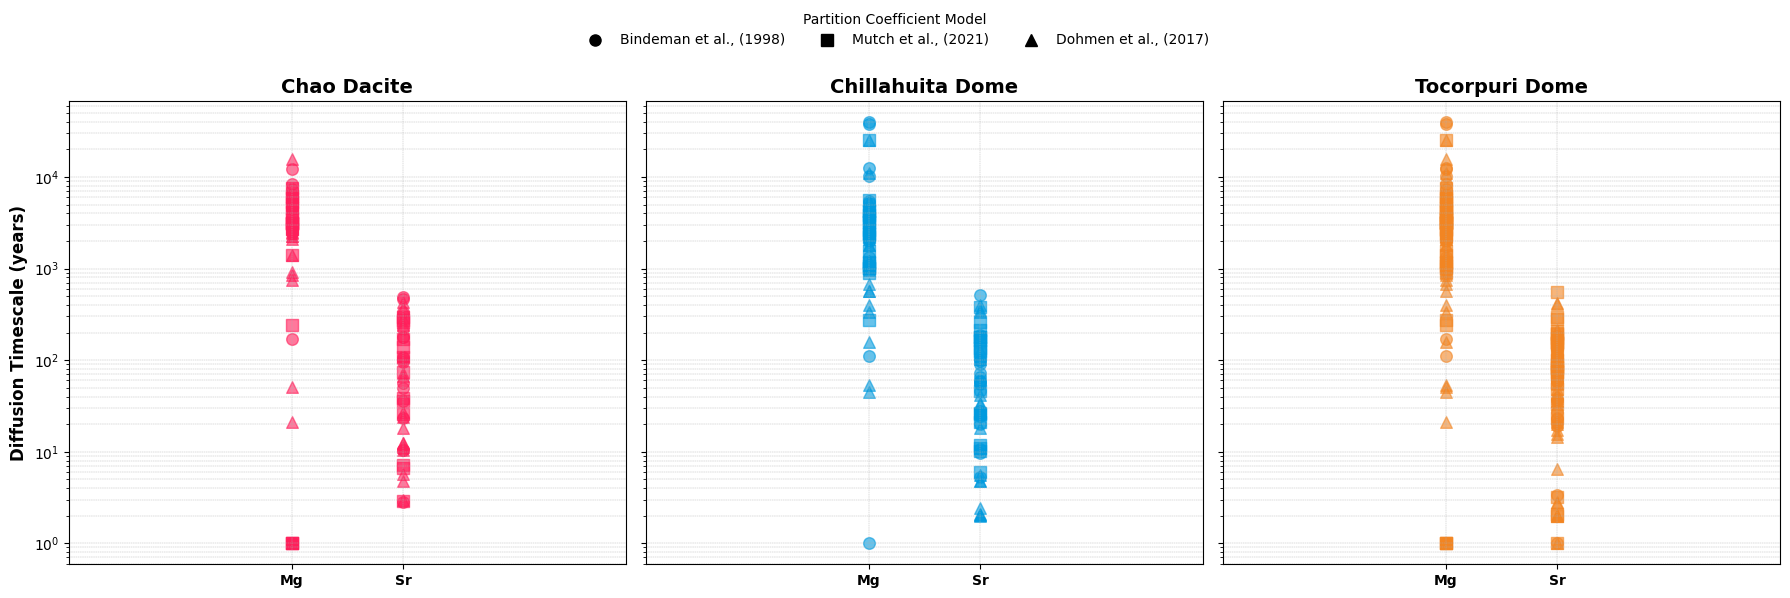

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Correct Excel file path
# -----------------------------
excel_file = (
    "/Users/bez/Library/CloudStorage/"
    "OneDrive-MissouriStateUniversity/"
    "THESIS/manuscripts/manuscript 2/model summary_all(mean_age).xlsx"
)

# -----------------------------
# Dome metadata (colors only now)
# -----------------------------
DOMES = {
    "Chao Dacite": {
        "sheet": "Chao",
        "color": "#FF1F5B"
    },
    "Chillahuita Dome": {
        "sheet": "Tort",
        "color": "#009ADE"
    },
    "Tocorpuri Dome": {
        "sheet": "Toto",
        "color": "#F28522"
    }
}

# -----------------------------
# Partition model → marker shapes
# -----------------------------
MODEL_MARKERS = {
    "Bindeman et al., (1998)": "o",
    "Mutch et al., (2021)": "s",
    "Dohmen et al., (2017)": "^"
}

# -----------------------------
# Read and tidy data
# -----------------------------
all_data = []

for dome, info in DOMES.items():

    df = pd.read_excel(excel_file, sheet_name=info["sheet"])

    df = df[df["Element"].isin(["Mg", "Sr"])]

    long = df.melt(
        id_vars=["Sample", "Grain", "Element"],
        value_vars=["Bindeman et al., (1998)", "Mutch et al., (2021)", "Dohmen et al., (2017)"],
        var_name="Partition_Model",
        value_name="mc_mean_yrs"
    )

    long["Dome"] = dome
    all_data.append(long)

data = pd.concat(all_data, ignore_index=True)

# Convert to numeric
data["mc_mean_yrs"] = pd.to_numeric(data["mc_mean_yrs"], errors="coerce")

# Remove missing
data = data.dropna(subset=["mc_mean_yrs"])

# Remove Sr outliers >1000
data = data[~((data["Element"] == "Sr") & (data["mc_mean_yrs"] > 750))]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Shift Mg and Sr toward the center
x_map = {"Mg": 0.4, "Sr": 0.6}

for ax, (dome, info) in zip(axes, DOMES.items()):
    subset = data[data["Dome"] == dome]

    for model in ["Bindeman et al., (1998)", "Mutch et al., (2021)", "Dohmen et al., (2017)"]:
        s = subset[subset["Partition_Model"] == model]

        ax.scatter(
            s["Element"].map(x_map),
            s["mc_mean_yrs"],
            color=info["color"],
            marker=MODEL_MARKERS[model],
            alpha=0.6,
            s=70,
            label=model
        )

    # Bold dome titles
    ax.set_title(dome, fontsize=14, fontweight="bold")

    # Bold x-axis tick labels
    ax.set_xticks([0.4, 0.6])
    ax.set_xticklabels(["Mg", "Sr"], fontsize=10, fontweight="bold")

    ax.set_xlim(0, 1)
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", linewidth=0.3)

# Bold y-axis label
axes[0].set_ylabel("Diffusion Timescale (years)", fontsize=12, fontweight="bold")

# Shared legend for partition models
handles = []
labels = []
for model in MODEL_MARKERS:
    handles.append(plt.Line2D([], [], color="black", marker=MODEL_MARKERS[model],
                              linestyle="None", markersize=8))
    labels.append(model)

fig.legend(
    handles,
    labels,
    title="Partition Coefficient Model",
    loc="upper center",
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('Model Ages', dpi=450, bbox_inches='tight', facecolor='white')
plt.show()
